# Notebook til 'Tidsafhængig kvantemekanik i én dimension'

In [17]:
import numpy as np
import matplotlib.pyplot as plt 

## Evaluering 

Da dette projekt forsøger at introducere en del nyt teori, er det passende at give en lille advarsel angående evalueringen af projektet. 

Projektet handler ikke om at forstå en masse kvantemekanik og skrive en masse ligninger op, men derimod at få skrevet noget kode og anvende nogle af de værktøjer vi har mødt i undervisningen. Evalueringen af projektet vil reflektere dette: Det vil som udgangspunkt ikke trække ned i point hvis i misforstår teorien bag kvantemekanikken eller de andre introducerede emner, så længe den kode der er skrevet er korrekt (i forhold til, hvad i mener at den skal gøre). På den anden side trækker det heller ikke meget op i point, at skrive om den præsenterede teori - fokus er på koden i sig selv. Det vil fx fylde mere i evalueringen at i grundigt kommenterer jeres kode og har god kodestil, end at i kommer med en forkert konklusion angående noget kvantemekanik. 

At opgaven har kvantemekanik som emne skal i stedet ses som et tilbud til at benytte noget programmering til at lære noget sejt fysik! 

## Opvarmning: Egentilstande af den kvantemekaniske harmoniske oscillator

I denne sektion vil vi introducere koncepterne fra noten hørende til projektet ved at betragte den harmoniske oscillator. Vi forestiller os en partikel med masse $m=1$ (fx en elektron i atomare enheder), der bevæger sig i potentialet: 

$V(x) = \frac{1}{2}\omega^2 x^2$

Vi vil numerisk finde egentilstandene for dette potential, og sammenligne med de analytiske udtryk fra projektnoten.

Først lidt om matricer i Python. Nedenstående celle viser et eksempel på hvordan matricer og vektorer kan defineres vha. numpy. 

In [5]:
# Definer 3x3 matrix 
A_mat = np.array([[1,2,3], 
                  [4,5,6], 
                  [7,8,9]])

# Vektorer er blot almindelige numpy arrays 
b_vec = np.array([1, 2, 3])

# Vi kan tage matrix - vektor produkt ved: 
mat_vec_prod = A_mat @ b_vec

print(mat_vec_prod)

[14 32 50]


Når vi repræsenterer vores Hamilton på det rummelige gitter (ligning 17 i noten), ser vi at den kun har elementer lige over og under diagonalen (super- og subdiagonalen). Man siger at matricen er tri-diagonal.

Der findes mange smarte rutiner for tridiagonale matricer, der simplificerer udregningerne en del og vi vil benytte nogle i det følgende. Derudover kan vi spare en del plads i computerens hukommelse, ved ikke at gemme alle indgangene der er nul. Vi bruger istedet en datastruktur, hvor vi kun gemmer båndet omkring diagonalen: 

In [ ]:
# Eksempel på datastruktur for tridiagonal matrix med størrelse (6 x 6)
# Vi gemmer kun superdiagonalen, diagonalen og subdiagonalen 

A_mat = np.zeros((3, 6))  # 3 for diagonalerne, 6 for størrelsen af matricen

# Tilfældig data 
A_sub_diag = [1,2,3,4,5]  # Sub diag har kun 5 indgange
A_super_diag = [1,2,3,4,5]  # Super diag har kun 5 indgange
A_diag = [6,7,8,9,10,11]  # Selve diag har 6 indgange 

# Sæt indgangene
A_mat[0,1:] = A_sub_diag  # Super diag har ikke noget i første kolonne 
A_mat[1,:] = A_diag
A_mat[2,:-1] = A_super_diag  # Sub diag har ikke noget i sidste kolonne 

print(A_mat)


[[ 0.  1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10. 11.]
 [ 1.  2.  3.  4.  5.  0.]]


Når vi har denne tridiagonale data-struktur kan vi ikke direkte benytte '@' fra numpy til at tage matrix produkter. Her i projektet skal vi kun benytte matrix-vektor produkter, dette kan let implementeres med vores datastruktur som:

In [1]:
# Funktion der udfører matrix-vektor multiplikaiton med matricen i vores tridiagonale struktur 
def banded_mv(A, x):
    n = A.shape[1]
    y = A[1,:] * x
    y[:-1] += A[0,1:] * x[1:]
    y[1:]  += A[2,:-1] * x[:-1]
    return y

Til at løse et matrix - vektor problem af formen $\bm A \bm x = \bm b$, vil vi igen udnytte at vi har et tridiagonal system. Her benytter vi scipy rutinen solve_banded. 
At løse et matrix-vektor system for en tridiagonal matrix er faktisk ikke så svært igen. Hvis man er interesseret findes en effektivt algoritme kaldet 'Thomas Algorithm' man selv kan kode: https://en.wikipedia.org/wiki/Tridiagonal_matrix_algorithm

In [ ]:
# Eksempel på at løse matrix - vektor ligningssystem 
from scipy.linalg import solve_banded

b_vec = np.array([1,2,3,4,5,6])

x_vec = solve_banded((1, 1), A_mat, b_vec)  # (1,1) er antal super/sub diagonaler

# Print løsningen 
print(x_vec)

# Check at løsningen er korrekt (og check at vores matrix-vektor mult routine fungerer)
print(banded_mv(A_mat, x_vec))

[0.1318496  0.20890237 0.2029169  0.31962002 0.12866729 0.48696942]
[1. 2. 3. 4. 5. 6.]


Det sidste vi mangler er at kunne finde egenværdier og egenvektorer for vores matricer. Alle matricer vi vil kigge på er symmetriske, dvs. elementerne på hver side af diagonalen er ens (se igen ligning 17 som eksempel). Symmetriske matricer har altid lige så mange egenværdier som dimensionen af matricen, dvs. for vores 6x6 matrix skal vi finde 6 egenværdier. Derudover er egenværdierne altid reelle. 

De numeriske rutiner for symmetriske matricer er meget effektive. Vi kan envidere udnytte at vi har en tridiagonal matrix hvilket giver endnu et boost. 

In [ ]:
# Eksempel på at finde egenværdier + egenvektorer for symmetrisk (generelt hermitisk) tridiagonal matrix 
from scipy.linalg import eigh_tridiagonal

eigvals, eigvecs = eigh_tridiagonal(A_mat[1,:], A_mat[0, 1:])  # Skal kun have diagonal + superdiagonal 

# Print egenværdierne, se at der er 6 og at de er reelle. 
print(eigvals)

[ 2.86292473  4.95859396  6.29852175  8.42322117 11.70834964 16.74838874]


In [16]:
# Check datastrukturen for egenvektorerne 
print(eigvecs)

[[-0.07031001  0.5851113   0.75678381  0.27889345 -0.04679718  0.00282802]
 [ 0.22056779 -0.60933844  0.22591643  0.67582052 -0.26713469  0.0303967 ]
 [-0.42109776  0.32939794 -0.45762964  0.34147431 -0.60548317  0.14674541]
 [ 0.57402511  0.07228134  0.108938   -0.40237396 -0.57035797  0.40766416]
 [-0.56488551 -0.32007801  0.26964882 -0.19808554  0.06793017  0.67962604]
 [ 0.34710599  0.26490357 -0.28677025  0.38436659  0.47949608  0.59114482]]


In [ ]:
# Hver kolonne svarer til en egenvektor. Check: 
vec0 = eigvecs[:,0]

# Tag matrix produkt og se om det svarer til at skalere med egenværdi 
vec_res = banded_mv(A_mat, vec0)

print(vec_res / vec0)

[2.86292473 2.86292473 2.86292473 2.86292473 2.86292473 2.86292473]


### Egenværdier og egenvektorer for et kvantesystem 
Nu hvor i har set de lineær algebra rutiner vi skal bruge, er det på tide at i får hænderne i noget kvantemekanik. Herunder følger en grov skitse af de trin der skal tages for at finde egentilstandene for den harmoniske oscialltor. 


**Byg Hamilton matricen for den harmoniske oscillator**
- Definer et x-gitter, vælg fx. et interval på $[-15,15]$ og 200 punkter. (Test gerne med større og mindre gitter)
- Konstruer $T$ og $V$ matricerne. Benyt $V$ for den harmoniske oscillator, og tag fx $\omega=2$ eller lignende.  
- Konsturer $H$ vha. ligning (17). 


**Diagonaliser!**
- Benyt rutinerne vist ovenover til at finde egenværdier og egentilstande. 


**Analysér!**
- Sammenlign de fundne egenværdier med de analytiske fra noten. Generelt vil kun de laveste værdier passe nogenlunde. 
- Plot $|\psi_n(x)|^2$ for et par af de laveste tilstande. Sammenlign med de analytiske resultater. HUSK at normalisere egentilstandene til jeres x-gitter. 

### Tidspropagation
Den harmoniske oscillator er også en god mulighed for at bygge og teste Crank-Nicholson metoden vi skal bruge til propagation i tid i det følgende. I dette tilfælde er potentialet ikke tidsafhængigt, dvs. $\bm H(t) = \bm H$. Vi behøver derfor kun at bygge matricerne til Crank-Nicholson propagation én gang. 

**Byg Crank-Nicholson matricerne**
- Vælg et tidsskridt for propagation, fx dt=0.1. 
- Byg de to Crank-Nicholson (CN) matrcier i ligning (19). 

**Propager!**
- Vælg en start-tilstand, $\psi(t_0)$. Tag først grundtilstanden fundet ovenover, dvs. den egentilstand med lavest energi. HUSK at normalisere din bølgefunktion! 
- Byg et for-loop, der looper hen over jeres tidsskridt. I hvert skridt skal i: (Se igen ligning 19 i noten)
    - Gange jeres tilstand ved den nuværende tid med CN-matricen der propagarer den et halv skridt fremad. 
    - Løs et matrix-vektor system med CN-matricen der propagerer bagud, for at finde jeres tilstand til næste tidsskridt.

**Analysér!**
- Lav evt. en animation af $|\psi(t)|^2$ (eller plot denne for forskellige tider undervejs). Hvad ser i? Er dette hvad i forventer? 
- Kan i finde på et mere interessant eksempel, hvor vi stadig kender løsningen? 
    - *Hint: Hvad sker der hvis startilstanden er summen af de to laveste egentilstande? (Normer starttilstanden efter i har taget summen!).*

**Når ovenstående kører, og i er overbeviste om at koden fungerer som den skal, er i klar til at gå videre til det egentlige projekt.**

I må simulere/undersøge lige det system i vil, især hvis der er noget særligt i synes kunne være interessant. For at give lidt at vælge imellem har jeg skitseret tre projekter i resten af notebooken.

## Spredning på en potentialbarriere 

Her vil vi se bevægelsen af en fri bølgepakke (fx en fri elektron), og hvad der sker, når den rammer en potential barriere (en 'mur'). Ved at kigge på sandsynlighedsdensiteten på begge sider af muren, vil vi forsøge at observere kvantetunnelering.

<br>

**Bølgefunktionen for en fri partikel**

Løsningen til den tidsuafhægnige Schrödingerligning for en fri partikel er givet ved en plan bølge 

$\psi(x) = \frac{1}{\sqrt{2\pi}}e^{ixk}$

hvor $k$ er partiklens bølgetal, i kvantemekanik relateret til partiklens energi ved (i atomare enheder)

$E = \frac{k^2}{2}$.

Denne tilstand kan ikke normaliseres (den svinger for evigt), så for at repræsentere en egentlig fri partikel bliver man nødt til at tage en superposition af disse. Fx kan vi ud fra disse danne en Gauss bølgepakke (denne detalje er lidt teknisk, spørg evt. instruktoren hvis i er interesserede): 

$\psi(x) = \frac{1}{(2\pi \sigma^2)^{1/4}} e^{-\frac{(x-x_0)^2}{4\sigma^2}} e^{ixk_0}$

Her er $\sigma$ relateret til bredden af bølgepakken i rum, $x_0$ er centeret for bølgepakken og $k_0$ er dens centrale hastighed. 

Det er vigtigt at bemærke, at bølgepakken indeholder flere forskellige bølgetal, og derfor i princippet en 'bredde' af energier. Fordelingen af bølgetal er også en Gauss, og vil have bredden $1/2\sigma$. Dette kan i benytte til at komme med et estimat for den maksimale 'energi'-komponent af bølgepakken.

<br>

**Spredning på en potential-barriere**

Vi vil undersøge hvad der sker, når vores partikel rammer en potential-barriere. Da vores kode kræver at potentialet er kontinuert, kan vi fx vælge denne mur som en smal Gauss 

$V(x) = V_0e^{-\frac{x^2}{4\sigma_m^2}}$

Her styrer $V_0$ højden af vores 'mur', og $\sigma_m$ bredden. I det klassiske tilfælde vil en partikel med energi $E<V_0$ ikke kunne komme om på den anden side af denne mur. I kvantetilfældet kan dette godt lade sig gøre, et fænomen der kaldes 'kvantetunnelering'. Sandsynligheden for tunnelering vil falde med tykkelsen af muren, samt forskellen på $E$ og $V_0$. .

<br>




### Projektforslag: 

**Opsætning**
- Start med at vælge et rummeligt gitter. Gitteret skal kunne indeholde hele jeres bølgepakke på begge sider af potentialet (som vi sætter i centeret). Det er vigtigt at bølgepakken IKKE rammer kanten af simuleringsboksen, da den dermed vil blive reflekteret og ødelægge simuleringen.
- Sørg for at have nok punkter i det rummelige gitter til, at bølgepakken + potentialet er godt repræsenteret. Tjek altid konvergens af simuleringerne ved at øge antallet og se at i får det samme.
- Her er et forslag til et parameter område i kan undersøge til at starte med: $x\in [-100, 100]$, $N_x=3000$, $dt=0.01$, $V_0=5$, $\sigma_m^2=0.025$, $E_0=k_0^2/2\sim 4$, $\sigma=5$. 

<br>

**Propager!**
- Byg en start-bølgefunktion (ud fra udtrykket af den Gaussiske bølgepakken ovenover), og lavt et plot af $|\psi(x,t=0)|^2$ sammen med jeres potential. Husk at checke normaliseringen af jeres tilstand!
- Byg jeres Crank-Nicholson matrix, og propager jeres tilstand som ovenover. 
- Lav fx en animation af $|\psi(x,t)|^2$, som den spreder på potentialet. Bølgefunktionen kan opføre sig meget spøjst. 
- Når bølgefunktionen har passeret / er blevet reflekteret og er væk fra potentialet igen kan i stoppe tidspropageringen. Beregn nu den totale sandsynlighed for at partiklen er på hhv. højre / venstre side, ved at integrere passende dele af $|\psi(x,t)|^2$. 

<br>

**Analyser!**
- Gentag ovenstående for flere forskellige start-hastigheder (energier), og lav et plot af sandsynligheden for at partiklen passerer barrieren, som funktion af energien. Kan i se tunnelering? 
- Prøv at variere forskellige størrelser: $V_0$, $\sigma_m$ osv. 
- I kan også lege med spredning på et tidsafhængigt potentiale (fx et der svinger som en harmonisk oscillator). Her skal i huske at opdatere Crank-Nicholson matricerne i hvert tidsskridt.

## Rabi-oscillationer i 1D hydrogen i et laser-felt 


I gymnasiet har i med garanti set Bohrs atommodel. I denne model kan elektronen i hydrogen befinde sig i forskellige 'skaller' svarende til forskellige energiniveauer af atomet. Hvis man kommer med en foton der har energien svarende til forskellen mellem to energiniveauer, kan den exictere atomet. 

I denne opgave vil vi vise disse effekter fra den tidsafhængige Schrödingerligning, dog kun i 1 dimension. 

<br>

**Model af 1D hydrogen**

Først skal vi have fat i det korrekte potential. I 3D (uden relativistiske effekter og under antagelsen af at protonen i hydrogen er fikseret), vil elektronen bevæge sig rundt i et Coulomb potential: 

$V(r) = -\frac{1}{r}$ 

På vores 1D gitter ville den naturlige oversættelse være $r \rightarrow x$. Dog har vi det problem at vi så har et divergerende potential, som vi ikke kan håndtere med det valgte gitter. Vi vælger istedet at regularisere (eller blødgøre) Coulomb potentialet ved at indføre en konstant 

$V_C(x) = -\frac{1}{\sqrt{x^2 + a}}$,

hvor vi typisk vælger $a=1$. Valget af $a$ afgør selvfølgelig hvilke energier egentilstandene har.

<br>

**Interaktion med en laser**

Vi antager i denne opgave, at vores hydrogen atom udsættes for et laser-felt, der er beskrevet ved bølgen

$E(t) = E_0 \sin(\omega t)$, 

hvor $E_0$ er amplituden af det elektriske felt (realteret til intensiteten) og $\omega$ er vinkelfrekvensen feltet svinger med. Fra Planck relationen ved vi at vinkelfrekvensen af laserlyset er relateret til foton-energien ved (i atomare enheder):

$E_p = \omega$

I vil bemærke at laser feltet ingen rummelig afhængighed har, hvilket skyldes at vi antager at bølgelængden af lyset er meget større end udstrækningen af atomet, og den rummelige afhængighed derfor kan ignoreres. Dette er den såkaldte *dipol-approksimation* og i atomfysik vil i lære at leddet i Hamiltonen, der bekskriver interaktionen mellem en elektron og et dipol laser felt er givet som 

$V_L(t) = x E(t)$

Vores totale potentiale er derfor: 

$V(x,t) = V_C(x) + V_L(x,t)$

<br>

**Laser inducerede exicationer**

Vi antager at laseren til tiden før $t=0$ er slukket, og at systemet befinder sig i grundtilstanden af $V_C$. Til $t=0$ tændes laseren og påvirker elektronen i systemet. Resultatet er, at flere af egentilstandene af vores system vil blive populeret. Hvis laseren er meget intens ($E_0$ stor), vil vi excitere mange tilstande og potentielt rive elektronen fri af atomet - vi har ioniseret atomet. Dette ser vi nærmere på i næste opgave, her holder vi $E_0$ lav i første omgang.

Istedet vælger vi at skrue på $\omega$. Hvis $\omega$ matcher energiforskellen mellem to af egentilstandende i vores system 

$\omega = \Delta E_i = E_i - E_0$,

siger vi at den er resonant med denne overgang, og vi vil flytte meget af populationen op i denne tilstand.

### Projektforslag:

**Egentilstande**
- Start med at finde egentilstandene og egenenergierne af vores 1D hydrogen model. 
- Plot nogle af egentilstandene - i vil se at kun dem med negative energier er 'bundne' til potential-brønden. 
- Forbred jeres laser: Vælg en $\omega$ der er lig med forskellen mellem den laveste egentilstand og den næstlaveste tilstand, $\omega = E_1-E_0 = \omega_{10}$. Vælg derudover et $E_0$ der ikke er for stor, fx $E_0=0.01$.

**Propager!**
- Som starttilstand tager vi egentilstanden med lavest energi. (Husk at normalisere)
- Lav jeres propagations loop, hvor i i hvert step skal bygge jeres Crank-Nicholson matricer. (Husk $H$ er tidsafhængig når laseren er tændt).
- Propager i et givet antal laser-cykler.
- Udregn i hvert tidsskridt populationen i de to egentilstande som laseren kobler. 

**Analyser!**
- Plot de udregnde populationer. Hvordan opfører systemet sig? 
- Er alt populationen i de to laveste tilstande? Hvad sker der hvis i skruer op for styrken af laseren? 
- Prøv at ændre $\omega$. Lav fx et scan af frekvenser omkring $\omega_{10}$. For hver frekvens kan i gemme populationen i den exciterede tilstand. Lav til sidst en animation i tid, hvor i plotter populationen i den exciterede tilstand for alle jeres frekvenser.   

**Hvis ovenstående kode fungerer, og man er frisk på lidt mere teori man kan sammenligne med, kan man gribe fat i instruktoren for mere info**

## Høj harmonisk generation fra 1D hydrogen i et stærkt laser-felt 

Denne opgave betragter også 1D hydrogen i et laserfelt. Denne gang skruer vi dog op for laseren, og ser at vores atom ioniserer. Hvis man er interesseret kan man også forsøge at simulere såkaldt 'høj harmonisk generation' (HHG). Det er lys udsendt fra atomet som respons på at blive drevet af den intense laser.

<br>

**Model og laserinteraktion**

Dette er det samme som forrige opgave. Kig derfor i teksten deroppe. Denne gang er vores laser dog lidt anderledes, da vi gerne vil simulere en laser-puls (istedt for en kontinuert tændt laser som før). Sådan en laser puls kan fx beskrives ved nedenstående funktion:


In [ ]:
def E_field(t, omega, Up, CEP, N_cycles): 
    t_fin_sin2 = 2.*np.pi*N_cycles/omega  # Længde af laserpulsen
    
    if t<0 or t>t_fin_sin2: 
        return 0
    else: 
        t_fac = omega*t/(2.*N_cycles)
        sin_fac = np.sin(t_fac)
        return -Up*omega * sin_fac * (np.cos(t_fac)*np.sin(omega*t+CEP)/N_cycles + sin_fac*np.cos(omega*t+CEP))

Her er $\omega$ grund-frekvensen af pulsen, $U_p$ er en amplitude-parameter, $CEP$ er en fase og $N_{cycles}$ er antallet af perioder, der er i laser pulsen. Pulsen går fra tiden $t=0$ til $t=\frac{2\pi N_{cycles}}{\omega}$. 
Prøv at lav et plot af denne laserpuls, og test at ovenstående parametre opfører sig som forventet. 

<br>

**Simulerings maske**

Når vi ioniserer atomet vil bølgepakken begynde at bevæge sig væk fra potentialet i centeret af vores rummelige gitter. Bølgepakken må ikke ramme kanten, idet det vil ødelægge vores simulering. Hvis laserpulsen er lang, risikerer vi derfor at skulle have meget store rummelige gitre, hvilket kan gøre simuleringen ret langsom.
Den simpleste løsning er at bruge en såkaldt 'maske' til at fjerne den del af bølgefunktionen, der nærmer sig kanten af gitteret. På den måde ødelægger vi teknisk set bølgefunktionen, men gøres det med en blød kontinuert maske, vil det ikke påvirke bølgefunktionen i den indre del af gitteret ret meget.
Normen (integralet af normkvadratet over hele rummet) af bølgefunktionen vil nu ikke længere være 1, idet vi fjerner noget af den. Den manglende norm lang tid efter laser-pulsen er slut, kan anses som sandsynligheden for at ionisere vore atom. 
Herunder gives et eksempel på en maske man kan benytte. Masken evalueres på det rummelige gitter, og ganges simpelt på sin bølgefunktion i slutningen af hver tidsskridt. 

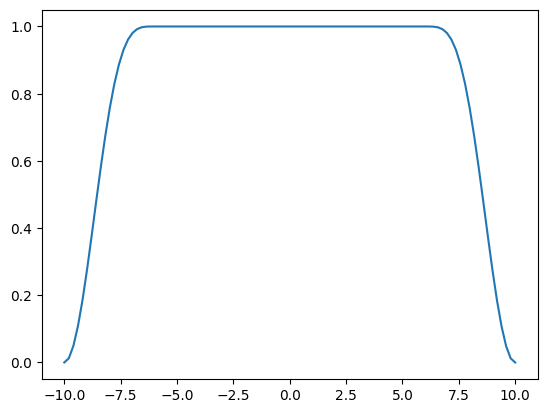

In [20]:
def mask(x, x_start, x_max, n_mask): 
    if abs(x) > x_start: 
        return 1 - np.cos(np.pi/2.*(x_max - abs(x))/(x_max - x_start))**n_mask
    else: 
        return 1 

x_test = np.linspace(-10, 10, 100)

x_start = 6  # Starten af masken i rum 
x_max = 10  # Maksimal værdi hvor masken bliver 0 (her er al bølgefunktionen fjernet)
n_mask = 4  # Potents der bestemmer stejlheden af masken

plt.plot(x_test, [mask(xi, x_start, x_max, n_mask) for xi in x_test])
plt.show()

**Udregning af HHG spektrum**

Fra elektromagnetisme ved vi at en oscillerende dipol udsender elektromagnetisk stråling. Det elektriske stråling vil være givet ved den tidsafledte af den oscillerende dipol. En dipol dannet af en ladet partikel er givet ved 

$\bm d = q \bm r$

hvor $q$ er ladningen af partiklen, og $\bm r$ er partiklens afstand fra origo. I vores tilfælde er ladningen $q$ ladningen af en elektron, i atomare enheder $q=-e=-1$. 

I kvantemekanik kan vi ikke finde dipolen direkte, men vi kan finde forventiningsværdien af den, hvilket af ovenstående må være det samme som forvetningsværdien af positionen gange et fortegn 

$\langle d_x\rangle(t) = -\langle x \rangle(t) = -\int_{-\infty}^{\infty} x |\psi(x,t)|^2 dx$

Hvis vi kan finde ovenstående til alle tider, og tage en tidsafledt, har vi dermed en størrelse relateret til det elektriske felt. Vi er mest interesseret i at se denne størrelse i frekvensrum (altså analysere hvilke frekvenser strålingen indeholder). Matematisk gøres dette ved at tage en såkaldt Fourier transformation. Funktionen der viser hvor meget af en given frekvens strålingen indeholder (spektret) er givet ved

$S(\omega) = |E(\omega)|^2  \propto \omega^2 \left|\int_{-\infty}^\infty e^{i\omega t} \langle x \rangle(t)\right|^2$

Vha. Crank-Nicholson propagation vil vi finde dipolen til forskellige tider, og derefter regne ovenstående integrale numerisk, fx vha. trapz integration.

### Projektforslag 

**Setup**
- Vælg fx:
    - $dt=0.1$
    - $x\in[-100,100]$, $N_x=2000$ 
    - $CEP=0$ 
    - $N_{cycles}=5-20$
    - $\omega = 0.057$ (800 nm)
    - $U_p=0.2196$ (svarende til en intensitet på $1\cdot 10^{14} \textit{W}/\textit{cm}^2$)

**Propagation!**
- Find som i forrige opgave egentilstande af 1D hydrogen potentialet, og start bølgefunktionen i egentilstanden med lavest energi. 
- Udfør propagation med Crank-Nicholson metoden. Husk at opdatere matrcierne i hvert step, og gang evt masken på. 
- I slutningen af hvert tidsskridt kan vi regne værdier af interesse. Hvis man vil simulere HHG, skal man fx regne forventningsværdien af positionen. 
- Når laser pulsen er slut, kan man propagere lidt længere i tid, for at sikre at al ioniseret bølgepakke når at ramme masken og blive absorberet. Herefter kan man regne ioniseringssandsynligheden, ved at regne integralet af $|\psi(x)|^2$ der er tilbage på gitteret.

**Analyser!**
- For ioniseringsandsynligheder: 
    - Kør fx ovenstående simulering for forskellige intensiteter, bølgelængder eller puls-længder, og undersøg hvordan ioniseringssandsynligheden afhænger af disse parametre. 
- For HHG: 
    - Efter simuleringen haves forventningsværdien af positionen til alle de simulerede tider. Udfør integralet ovenover for at finde spektraet.
    - Plot fx dit spektra på et plot med logaritmisk y-akse. I skal gerne se tydelige peaks ved frekvenser der matcher $n\cdot \omega$, hvor $n$ er et positivt heltal.